# Workshop 2: Why overlap-based labeling can fail

A simple idea is:

For each dressed eigenstate, find the bare state with the largest overlap, and use that as the label.

This works well when coupling is weak and mixing is small.
But it can fail when states hybridize strongly.

This notebook demonstrates that problem.

In [16]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

In [17]:
tmon = scq.Transmon(
    EJ=30.0,
    EC=1.2,
    ng=0.0,
    ncut=31,
    truncated_dim=3
)

res = scq.Oscillator(
    E_osc=6.0,
    truncated_dim=5
)


hilbertspace = scq.HilbertSpace([tmon, res])

g = 0.8

hilbertspace.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
)

evals, evecs = hilbertspace.eigensys(evals_count=12) # 12 dressed eigentstates

## Step 1. Build the bare product basis explicitly

## Step 2. Compute bare-state overlap weights

For each dressed eigenvector, we compute its probability weight in each bare basis state.

In [18]:
bare_states = []
for t in range(tmon.truncated_dim):
    for r in range(res.truncated_dim):
        bare_states.append((t, r))

print(bare_states)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]


In [19]:
overlap_table = np.abs(np.array([evecs[i].full().flatten() for i in range(len(evecs))]))**2
print("Shape of overlap table:", overlap_table.shape)

Shape of overlap table: (12, 15)


Convention reminder:

- columns typically correspond to dressed eigenstates
- rows typically correspond to bare basis states

We now find the most dominant bare component for each dressed state.

In [20]:
dominant_labels = []
dominant_probs = []

for k in range(overlap_table.shape[1]):
    probs = overlap_table[:, k]
    max_idx = np.argmax(probs)
    dominant_labels.append(bare_states[max_idx])
    dominant_probs.append(probs[max_idx])

for k in range(len(dominant_labels)):
    print(f"dressed {k:2d}: dominant bare label = {dominant_labels[k]}, weight = {dominant_probs[k]:.4f}")

dressed  0: dominant bare label = (0, 0), weight = 0.9989
dressed  1: dominant bare label = (0, 1), weight = 0.9922
dressed  2: dominant bare label = (0, 2), weight = 0.9856
dressed  3: dominant bare label = (0, 4), weight = 0.9792
dressed  4: dominant bare label = (1, 1), weight = 0.9779
dressed  5: dominant bare label = (0, 3), weight = 0.9922
dressed  6: dominant bare label = (1, 0), weight = 0.9698
dressed  7: dominant bare label = (1, 2), weight = 0.9491
dressed  8: dominant bare label = (1, 4), weight = 0.9297
dressed  9: dominant bare label = (2, 1), weight = 0.9473
dressed 10: dominant bare label = (1, 3), weight = 0.9863
dressed 11: dominant bare label = (2, 0), weight = 0.9716
dressed 12: dominant bare label = (1, 4), weight = 0.0367
dressed 13: dominant bare label = (2, 1), weight = 0.0478
dressed 14: dominant bare label = (1, 4), weight = 0.0085


## Step 3. Plot the dominant overlap weight

If the maximum overlap is close to 1, labeling is easy.
If it is much smaller, the dressed state is strongly mixed.

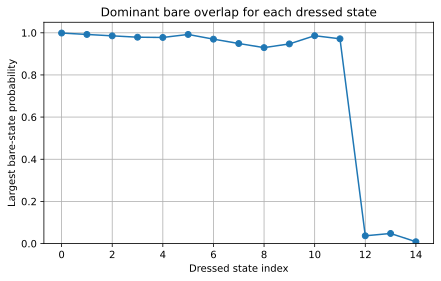

In [21]:
plt.figure(figsize=(7,4))
plt.plot(range(len(dominant_probs)), dominant_probs, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Largest bare-state probability")
plt.ylim(0, 1.05)
plt.title("Dominant bare overlap for each dressed state")
plt.grid(True)
plt.show()

## Step 4. Inspect a strongly mixed state

In [22]:
k = int(np.argmin(dominant_probs))
probs = overlap_table[:, k]

sorted_indices = np.argsort(probs)[::-1]

print(f"Most mixed dressed state among inspected states: k = {k}")
print("Top bare components:")

for idx in sorted_indices[:5]:
    print(f"bare {bare_states[idx]}: {probs[idx]:.4f}")

Most mixed dressed state among inspected states: k = 14
Top bare components:
bare (1, 4): 0.0085
bare (1, 1): 0.0001
bare (0, 2): 0.0000
bare (1, 3): 0.0000
bare (1, 0): 0.0000


## Step 5. Compare DE and LX label generation

Now compare the default overlap-style assignment against branch analysis.

In [23]:
hilbertspace.generate_lookup(ordering="DE")
print("Generated DE lookup")

de_labels = []
for k in range(12):
    try:
        de_labels.append(hilbertspace.bare_index(k))
    except Exception:
        de_labels.append(None)

hilbertspace.generate_lookup(ordering="LX")
print("Generated LX lookup")

lx_labels = []
for k in range(12):
    try:
        lx_labels.append(hilbertspace.bare_index(k))
    except Exception:
        lx_labels.append(None)

for k in range(12):
    print(f"{k:2d}: DE {de_labels[k]}    LX {lx_labels[k]}")

Generated DE lookup
Generated LX lookup
 0: DE (0, 0)    LX (0, 0)
 1: DE (0, 1)    LX (0, 1)
 2: DE (0, 2)    LX (0, 2)
 3: DE (1, 0)    LX (1, 0)
 4: DE (0, 3)    LX (0, 3)
 5: DE (1, 1)    LX (1, 1)
 6: DE (0, 4)    LX (0, 4)
 7: DE (1, 2)    LX (1, 2)
 8: DE (2, 0)    LX (2, 0)
 9: DE (1, 3)    LX (1, 3)
10: DE (2, 1)    LX (2, 1)
11: DE (1, 4)    LX (1, 4)


If some accessor does not behave as expected in your local version, inspect:

- `hilbertspace.lookup`
- `hilbertspace._lookup`
- `help(hilbertspace.generate_lookup)`

The conceptual purpose of this section is to see that DE and LX can differ.
That difference is exactly why branch analysis exists.

# Forcing strong hybridization

In [24]:
tmon = scq.Transmon(
    EJ=30.0,
    EC=1.2,
    ng=0.0,
    ncut=31,
    truncated_dim=3
)

res = scq.Oscillator(
    E_osc=15.8,
    truncated_dim=5
)


hilbertspace = scq.HilbertSpace([tmon, res])

g = 0.8

hilbertspace.add_interaction(
    g_strength=g,
    op1=tmon.n_operator,
    op2=res.creation_operator,
    add_hc=True # Adding the Hermitian conjugate of the interaction term. 
)

evals, evecs = hilbertspace.eigensys(evals_count=12) # 12 dressed eigentstates

## Step 1. Build the bare product basis explicitly

## Step 2. Compute bare-state overlap weights

For each dressed eigenvector, we compute its probability weight in each bare basis state.

In [25]:
bare_states = []
for t in range(tmon.truncated_dim):
    for r in range(res.truncated_dim):
        bare_states.append((t, r))

print(bare_states)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4)]


In [26]:
overlap_table = np.abs(np.array([evecs[i].full().flatten() for i in range(len(evecs))]))**2
print("Shape of overlap table:", overlap_table.shape)

Shape of overlap table: (12, 15)


Convention reminder:

- columns typically correspond to dressed eigenstates
- rows typically correspond to bare basis states

We now find the most dominant bare component for each dressed state.

In [27]:
dominant_labels = []
dominant_probs = []

for k in range(overlap_table.shape[1]):
    probs = overlap_table[:, k]
    max_idx = np.argmax(probs)
    dominant_labels.append(bare_states[max_idx])
    dominant_probs.append(probs[max_idx])

for k in range(len(dominant_labels)):
    print(f"dressed {k:2d}: dominant bare label = {dominant_labels[k]}, weight = {dominant_probs[k]:.4f}")

dressed  0: dominant bare label = (0, 0), weight = 0.9995
dressed  1: dominant bare label = (0, 2), weight = 0.5446
dressed  2: dominant bare label = (0, 4), weight = 0.5284
dressed  3: dominant bare label = (1, 2), weight = 0.5608
dressed  4: dominant bare label = (2, 0), weight = 0.5711
dressed  5: dominant bare label = (0, 1), weight = 0.5446
dressed  6: dominant bare label = (1, 0), weight = 0.5145
dressed  7: dominant bare label = (1, 3), weight = 0.5303
dressed  8: dominant bare label = (2, 1), weight = 0.5252
dressed  9: dominant bare label = (1, 2), weight = 0.0012
dressed 10: dominant bare label = (0, 3), weight = 0.7303
dressed 11: dominant bare label = (1, 1), weight = 0.6298
dressed 12: dominant bare label = (1, 4), weight = 0.5783
dressed 13: dominant bare label = (1, 3), weight = 0.0017
dressed 14: dominant bare label = (2, 1), weight = 0.0025


## Step 3. Plot the dominant overlap weight

If the maximum overlap is close to 1, labeling is easy.
If it is much smaller, the dressed state is strongly mixed.

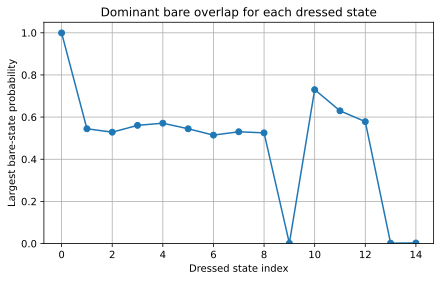

In [28]:
plt.figure(figsize=(7,4))
plt.plot(range(len(dominant_probs)), dominant_probs, marker='o')
plt.xlabel("Dressed state index")
plt.ylabel("Largest bare-state probability")
plt.ylim(0, 1.05)
plt.title("Dominant bare overlap for each dressed state")
plt.grid(True)
plt.show()

## Step 4. Inspect a strongly mixed state

In [29]:
k = int(np.argmin(dominant_probs))
probs = overlap_table[:, k]

sorted_indices = np.argsort(probs)[::-1]

print(f"Most mixed dressed state among inspected states: k = {k}")
print("Top bare components:")

for idx in sorted_indices[:5]:
    print(f"bare {bare_states[idx]}: {probs[idx]:.4f}")

Most mixed dressed state among inspected states: k = 9
Top bare components:
bare (1, 2): 0.0012
bare (1, 3): 0.0007
bare (1, 1): 0.0002
bare (0, 2): 0.0000
bare (0, 1): 0.0000


## Step 5. Compare DE and LX label generation

Now compare the default overlap-style assignment against branch analysis.

In [30]:
hilbertspace.generate_lookup(ordering="DE")
print("Generated DE lookup")

de_labels = []
for k in range(12):
    try:
        de_labels.append(hilbertspace.bare_index(k))
    except Exception:
        de_labels.append(None)

hilbertspace.generate_lookup(ordering="LX")
print("Generated LX lookup")

lx_labels = []
for k in range(12):
    try:
        lx_labels.append(hilbertspace.bare_index(k))
    except Exception:
        lx_labels.append(None)

for k in range(12):
    print(f"{k:2d}: DE {de_labels[k]}    LX {lx_labels[k]}")

Generated DE lookup
Generated LX lookup
 0: DE (0, 0)    LX (0, 0)
 1: DE (1, 0)    LX (1, 0)
 2: DE (0, 1)    LX (0, 1)
 3: DE (2, 0)    LX (2, 0)
 4: DE (0, 2)    LX (1, 1)
 5: DE (1, 1)    LX (0, 2)
 6: DE (2, 1)    LX (2, 1)
 7: DE (0, 3)    LX (1, 2)
 8: DE (1, 2)    LX (0, 3)
 9: DE (2, 2)    LX (2, 2)
10: DE (0, 4)    LX (1, 3)
11: DE (1, 3)    LX (0, 4)


If some accessor does not behave as expected in your local version, inspect:

- `hilbertspace.lookup`
- `hilbertspace._lookup`
- `help(hilbertspace.generate_lookup)`

The conceptual purpose of this section is to see that DE and LX can differ.
That difference is exactly why branch analysis exists.

## Exercises

1. Sweep `g` over:
   - 0.1
   - 0.3
   - 0.6
   - 1.0

   For each value, plot the dominant bare overlap.

2. Find the first dressed state whose dominant overlap drops below 0.7.

3. Compare DE and LX assignments at weak coupling and strong coupling.
   When do they begin to differ?

## Takeaway

You should now see that:

- overlap-based labeling is local and greedy
- strong hybridization can make that ambiguous
- branch analysis is designed to construct labels more systematically